#  Image Classification with TensorFlow

**Simple CNN** | Build a convolutional neural network from scratch


**Dataset:** CIFAR-10 (60,000 images, 10 classes: airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)


**Step 0A**   — (Optional) Mount Google Drive

Mount Drive if you want to **save your trained models** so they persist after the Colab session ends.
Skip this cell if you don't need to save models.

In [ ]:
SAVE_MODELS_TO_DRIVE = True  # ← Set to True to enable Drive saving

if SAVE_MODELS_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/cnn_tutorial_models/'
    import os
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f" Drive mounted. Models will be saved to: {SAVE_DIR}")
else:
    SAVE_DIR = '/content/'   # temporary Colab storage
    print("  Drive not mounted. Models saved to temporary Colab storage.")
    print("   They will be lost when the session ends.")

Mounted at /content/drive
 Drive mounted. Models will be saved to: /content/drive/MyDrive/cnn_tutorial_models/


##  Step 0B — Imports

TensorFlow, Keras, and plotting libraries come pre-installed in Colab — no `pip install` needed!

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110   # crisper figures in Colab

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import time, os

# Seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f" TensorFlow : {tf.__version__}")
print(f" Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f" GPUs found : {len(gpus)}  →  {'GPU training active' if gpus else 'CPU only'}")

 TensorFlow : 2.20.0
 Keras      : 3.13.2
 GPUs found : 1  →  GPU training active 🚀


---
##  Step 1 — Load and Explore the Dataset

In [ ]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Downloading CIFAR-10 (first run only, ~170 MB)...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("\nDataset loaded!")
print(f"  Training images : {x_train.shape}  → (samples, height, width, channels)")
print(f"  Test images     : {x_test.shape}")
print(f"  Pixel range     : {x_train.min()} – {x_train.max()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Dataset loaded!
  Training images : (50000, 32, 32, 3)  → (samples, height, width, channels)
  Test images     : (10000, 32, 32, 3)
  Pixel range     : 0 – 255


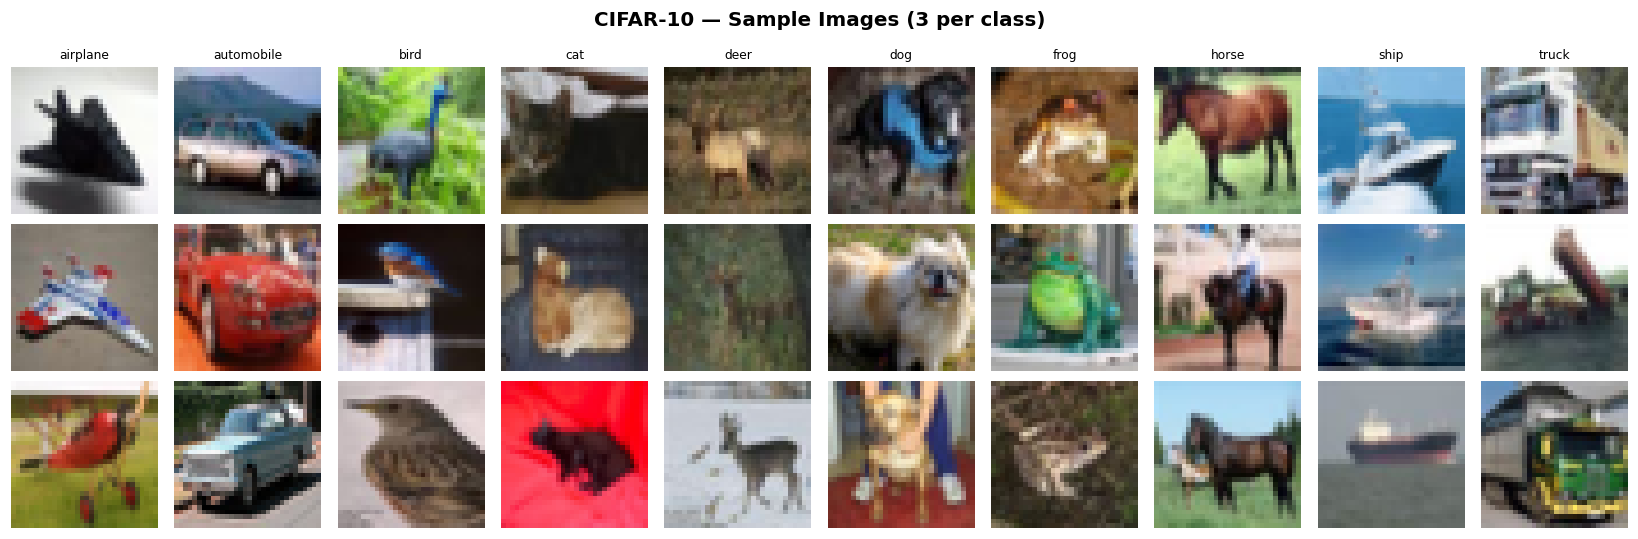

In [ ]:
# Show 3 examples of each class
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('CIFAR-10 — Sample Images (3 per class)', fontsize=13, fontweight='bold')

for class_idx in range(10):
    class_images = x_train[y_train.flatten() == class_idx][:3]
    for row in range(3):
        axes[row, class_idx].imshow(class_images[row])
        axes[row, class_idx].axis('off')
        if row == 0:
            axes[row, class_idx].set_title(CLASS_NAMES[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixels [0, 255] → [0.0, 1.0]
# Neural networks train much better with small, consistent input values
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten labels (N, 1) → (N,)
y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print(f" Pixel range after normalization : {x_train_norm.min()} – {x_train_norm.max()}")
print(f" Label shape  : {y_train_flat.shape} | Classes : {np.unique(y_train_flat)}")

 Pixel range after normalization : 0.0 – 1.0
 Label shape  : (50000,) | Classes : [0 1 2 3 4 5 6 7 8 9]


---
## Part 1 — Simple CNN from Scratch

### What is a CNN?
A **Convolutional Neural Network (CNN)** is specially designed for image data. It learns by stacking:

- **`Conv2D`** — detect local patterns: edges → textures → shapes → objects
- **`BatchNormalization`** — stabilise and speed up training
- **`MaxPooling2D`** — shrink spatial size (less memory, more efficient)
- **`Dropout`** — randomly disable neurons to prevent overfitting
- **`Dense`** — final classifier using the learned features

```
Input (32×32×3)
  → [Conv2D → BN → ReLU → MaxPool → Dropout] × 3   ← feature extraction
  → Flatten
  → [Dense → Dropout]                               ← classification
  → Softmax (10 classes)
```

In [ ]:
def build_simple_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Simple CNN built from scratch.

    Block 1: Conv(32)  → BN → ReLU → Pool  → Dropout(0.25)
    Block 2: Conv(64)  → BN → ReLU → Pool  → Dropout(0.25)
    Block 3: Conv(128) → BN → ReLU → Pool  → Dropout(0.25)
    Head   : Flatten → Dense(256) → Dropout(0.5) → Softmax(10)
    """
    model = models.Sequential(name='Simple_CNN')

    # Block 1 ── 32 filters, output: 16×16
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 32×32 → 16×16
    model.add(layers.Dropout(0.25))

    # Block 2 ── 64 filters, output: 8×8
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 16×16 → 8×8
    model.add(layers.Dropout(0.25))

    # Block 3 ── 128 filters, output: 4×4
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 8×8 → 4×4
    model.add(layers.Dropout(0.25))

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))  # probability per class

    return model


cnn_model = build_simple_cnn()
cnn_model.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # labels are plain integers
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, verbose=1)
]

print(" Training Simple CNN  (should take ~3–5 min on T4 GPU)...")
t0 = time.time()
cnn_history = cnn_model.fit(
    x_train_norm, y_train_flat,
    validation_split=0.15,
    epochs=15,
    batch_size=64,
    callbacks=callbacks_cnn,
    verbose=1
)
print(f"\n  Training time: {(time.time()-t0)/60:.1f} min")

 Training Simple CNN  (should take ~3–5 min on T4 GPU)...
Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.3725 - loss: 1.7632 - val_accuracy: 0.3064 - val_loss: 2.8248 - learning_rate: 0.0010
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4978 - loss: 1.3945 - val_accuracy: 0.5689 - val_loss: 1.2118 - learning_rate: 0.0010
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5604 - loss: 1.2344 - val_accuracy: 0.5373 - val_loss: 1.2954 - learning_rate: 0.0010
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6049 - loss: 1.1229 - val_accuracy: 0.6256 - val_loss: 1.0706 - learning_rate: 0.0010
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6362 - loss: 1.0434 - val_accuracy: 0.7019 - val_loss: 0.8550 - learning_rate: 0.0010
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6601 - loss: 0.9778 - val_accuracy: 0.6753 - val_loss: 0.9526 - learning_rate: 0.0010
Epoch 7/15
665/665 ━━━━━━━━━

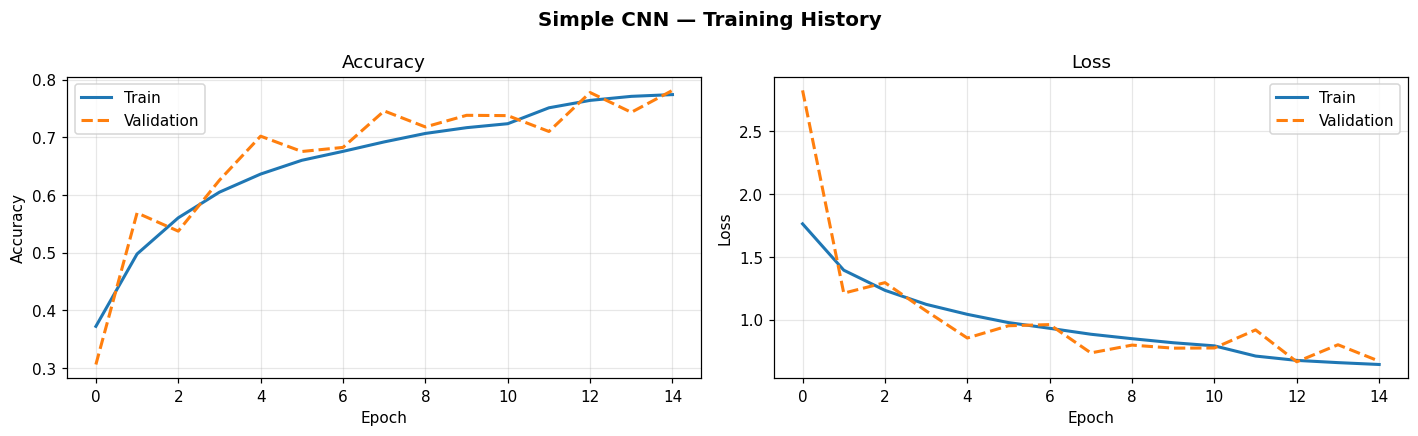


 Simple CNN — Test Accuracy : 76.74%
 Simple CNN — Test Loss     : 0.7085


In [ ]:
def plot_history(history, title='Training History'):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, metric, ylabel in [
        (ax1, 'accuracy', 'Accuracy'),
        (ax2, 'loss',     'Loss')
    ]:
        ax.plot(history.history[metric],         label='Train',      linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--')
        ax.set_title(ylabel)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(cnn_history, 'Simple CNN — Training History')

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print(f"\n Simple CNN — Test Accuracy : {cnn_acc*100:.2f}%")
print(f" Simple CNN — Test Loss     : {cnn_loss:.4f}")

In [ ]:
# Save the CNN model (to Drive if mounted, else to /content/)
cnn_save_path = os.path.join(SAVE_DIR, 'simple_cnn.keras')
cnn_model.save(cnn_save_path)
print(f" Model saved → {cnn_save_path}")

 Model saved → /content/drive/MyDrive/cnn_tutorial_models/simple_cnn.keras
